# 2. Metrics

Scores the full-CAH detections. Needs no GPU. Reads what `01_full_cah` wrote to
`results/`.

This is where the evaluation questions get answered: precision, recall and F1
at two matching radii, counting error, aggregate count bias, and the
false-positive rate on patches that contain no animals.

**Required caption for any reported result.** `caribou-owl-c` is an in-domain
reference and its documented operating point was selected on CAH test patches.
`owl-c`, `owl-t` and `owl-d` are general overhead models used zero-shot. This is
not a symmetric comparison and must not be presented as one.

**And the interpretation guard.** The development domain is PCH Alaska 2017; the
test domain is CAH Alaska 2022. Different herds, different areas, different
years. These numbers measure model transfer, not population change.

The radii vary only the distance at which a detection counts as matching an
annotation. They are not a confidence sweep: the detections were already
filtered by a threshold relative to each patch's own peak, so a genuine sweep
would have to re-extract from the heatmaps.


In [9]:
# --- 0. Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# --- 1. Configuration ---
ASSETS  = "/content/drive/MyDrive/OWL_Caribou_Project"
RESULTS = "/content/drive/MyDrive/owl_caribou_overhead/results"

RUN_NAME = "full_cah"
MODELS   = ["owl-d", "caribou-owl-c", "owl-c", "owl-t"]
RADII    = [20.0, 40.0]          # matching radii in patch pixels; 20 is the headline
PRIMARY  = "owl-d"

from pathlib import Path
if not (Path(ASSETS) / "data" / "test" / "gt.csv").is_file():
    raise RuntimeError(f"{ASSETS}/data/test/gt.csv not found. Put the assets there as the README's "
                       "'Expected assets' section describes, or point ASSETS at where they are.")


In [ ]:
# === CODE SYNC (auto-generated by `python -m owlcaribou.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m owlcaribou.sync   and reopen this notebook.")

In [12]:
# --- 3. Start the session (no GPU needed) ---
from owlcaribou.session import start_session

session = start_session(assets=ASSETS, results=RESULTS,
                        require_gpu=False, verify_assets=False)

session: Colab | device cuda (NVIDIA A100-SXM4-40GB, 39.49 GB)
  torch   2.11.0+cu128 | CUDA 12.8 | Python 3.13.15
  assets  /content/drive/MyDrive/OWL_Caribou_Project
  results /content/drive/MyDrive/owl_caribou_overhead/results
  code    c26c4d3f466e


In [13]:
# --- 4. Load the ground truth and every model's detections ---
from owlcaribou import io as oio, metrics
from owlcaribou.data import load_ground_truth, verify_mosaic_rule

truth = load_ground_truth(session.paths.ground_truth)

# Patch names come from a completed run, so we score exactly what was run
# rather than whatever happens to be on disk now.
reference = session.paths.run_dir(RUN_NAME, PRIMARY)
patch_names = [row["images"] for row in oio.read_csv(reference / "per_image.csv")]
assert len(patch_names) == 2607, f"expected 2607 evaluated patches, found {len(patch_names)}"
verify_mosaic_rule(patch_names, truth)   # the counts table labels patches by this rule

# Every model must be complete and come from one run of one code version.
run_code = oio.require_one_run(session.paths.run_dir(RUN_NAME), MODELS)
print(f"detections: one run of all {len(MODELS)} models, code {run_code}")

predictions = {}
for model in MODELS:
    directory = session.paths.run_dir(RUN_NAME, model)
    predictions[model] = metrics.load_predictions(directory / "detections.csv")
    total = sum(len(v) for v in predictions[model].values())
    print(f"{model:16s} {total:6d} detections on {len(predictions[model]):5d} patches")

print()
print(f"ground truth: {truth.total_points} points on {len(truth.points)} patches, "
      f"{len(patch_names) - len(truth.points)} empty")

detections: one run of all 4 models, code c26c4d3f466e
owl-d             12494 detections on  1837 patches
caribou-owl-c     13610 detections on  1896 patches
owl-c             12774 detections on  1850 patches
owl-t             11976 detections on  1838 patches

ground truth: 12456 points on 1852 patches, 755 empty


In [14]:
# --- 5. Detection and counting metrics ---
rows = metrics.score_radii(predictions, truth, patch_names, RADII)
oio.write_csv(session.paths.run_dir(RUN_NAME) / "metrics.csv", rows)

header = ("model".ljust(16) + "   r" + "  prec" + "   rec" + "    F1"
          + "   MAE" + "  RMSE" + "   bias%" + "  emptyFP")
print(header)
print("-" * len(header))
for row in rows:
    print(f"{row['model']:16s} {row['radius']:4.0f} {row['precision']:6.3f} "
          f"{row['recall']:6.3f} {row['f1_score']:6.3f} {row['count_mae']:6.2f} "
          f"{row['count_rmse']:6.2f} {row['aggregate_count_bias_percent']:+7.1f} "
          f"{row['empty_patch_false_positive_rate']:8.3f}")

print()
print("caribou-owl-c is in-domain with an operating point chosen on CAH;")
print("the others are zero-shot. Not a symmetric comparison.")

model              r  prec   rec    F1   MAE  RMSE   bias%  emptyFP
-------------------------------------------------------------------
owl-d              20  0.961  0.964  0.962   0.28   0.67    +0.3    0.013
owl-d              40  0.962  0.965  0.964   0.28   0.67    +0.3    0.013
caribou-owl-c      20  0.906  0.990  0.946   0.49   1.13    +9.3    0.062
caribou-owl-c      40  0.907  0.991  0.947   0.49   1.13    +9.3    0.062
owl-c              20  0.846  0.868  0.857   0.98   2.33    +2.6    0.065
owl-c              40  0.851  0.872  0.861   0.98   2.33    +2.6    0.065
owl-t              20  0.891  0.857  0.874   0.84   1.90    -3.9    0.049
owl-t              40  0.896  0.862  0.879   0.84   1.90    -3.9    0.049

caribou-owl-c is in-domain with an operating point chosen on CAH;
the others are zero-shot. Not a symmetric comparison.


owl-d: patch MAE 0.282 | RMSE 0.665 | mean signed bias +0.015
  aggregate count bias +0.31%  (predicted 12494 vs 12456 annotated)
  empty patches 755, false-positive rate 0.013, mean false count 0.021


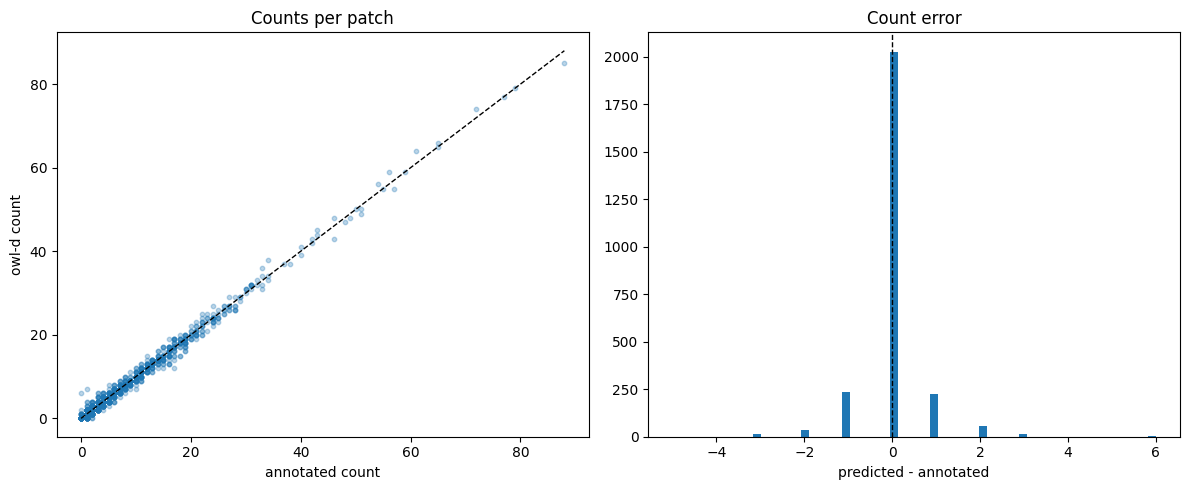

In [15]:
# --- 6. Counting diagnostics for the primary model ---
import math
import matplotlib.pyplot as plt
import numpy as np

counts = metrics.count_table(predictions[PRIMARY], truth, patch_names)
oio.write_csv(session.paths.run_dir(RUN_NAME) / f"{PRIMARY}_counts.csv", counts)

error = np.array([r["error"] for r in counts], dtype=float)
actual = np.array([r["actual"] for r in counts], dtype=float)
predicted = np.array([r["predicted"] for r in counts], dtype=float)
empty = actual == 0

print(f"{PRIMARY}: patch MAE {np.abs(error).mean():.3f} | "
      f"RMSE {math.sqrt((error ** 2).mean()):.3f} | "
      f"mean signed bias {error.mean():+.3f}")
print(f"  aggregate count bias {100 * error.sum() / actual.sum():+.2f}%  "
      f"(predicted {int(predicted.sum())} vs {int(actual.sum())} annotated)")
print(f"  empty patches {int(empty.sum())}, "
      f"false-positive rate {(predicted[empty] > 0).mean():.3f}, "
      f"mean false count {predicted[empty].mean():.3f}")

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(actual, predicted, s=10, alpha=0.3)
limit = max(actual.max(), predicted.max())
axes[0].plot([0, limit], [0, limit], "k--", linewidth=1)
axes[0].set_xlabel("annotated count")
axes[0].set_ylabel(f"{PRIMARY} count")
axes[0].set_title("Counts per patch")
axes[1].hist(error, bins=60)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted - annotated")
axes[1].set_title("Count error")
plt.tight_layout()
plt.savefig(session.paths.run_dir(RUN_NAME) / f"{PRIMARY}_counts.png", dpi=160)
plt.show()

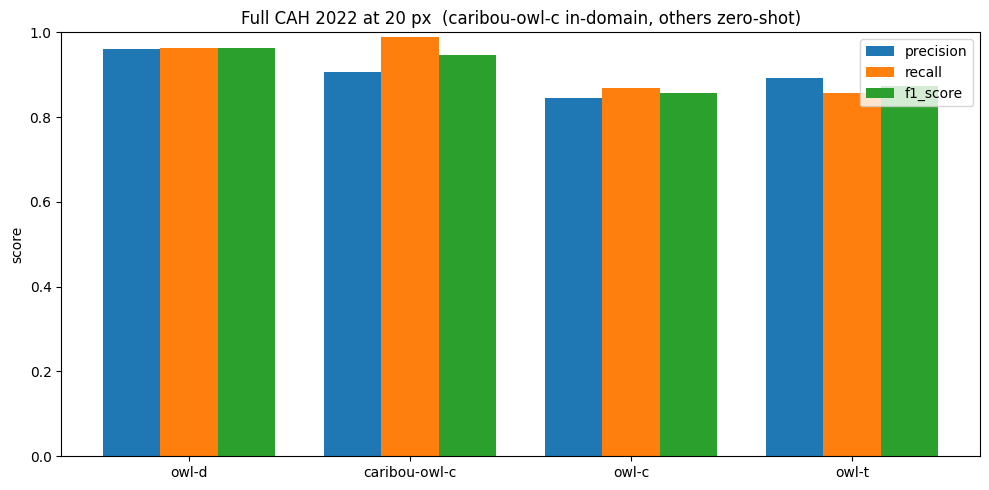

In [16]:
# --- 7. Model comparison at the headline radius ---
import matplotlib.pyplot as plt
import numpy as np

headline = [r for r in rows if r["radius"] == RADII[0]]
labels = [r["model"] for r in headline]
measures = ["precision", "recall", "f1_score"]
positions = np.arange(len(labels))
width = 0.26

plt.figure(figsize=(10, 5))
for offset, measure in enumerate(measures):
    plt.bar(positions + (offset - 1) * width,
            [r[measure] for r in headline], width, label=measure)
plt.xticks(positions, labels)
plt.ylim(0, 1)
plt.ylabel("score")
plt.title(f"Full CAH 2022 at {RADII[0]:.0f} px  "
          f"(caribou-owl-c in-domain, others zero-shot)")
plt.legend()
plt.tight_layout()
plt.savefig(session.paths.run_dir(RUN_NAME) / "model_comparison.png", dpi=160)
plt.show()

## Reading these numbers

**Compare radii before believing a difference.** A model that gains a lot going
from 20 px to 40 px is localising loosely rather than detecting better. One that
barely changes is placing points accurately.

**Aggregate bias and MAE say different things.** Bias near zero with a large MAE
means over- and under-counting cancel across patches - good for a total,
unreliable for any single patch.

**The empty-patch false-positive rate stands alone.** It uses the 755 patches
with no animals and is the number that matters for surveying: how often the
model invents animals on empty ground.

## Still not claimed

- population change - different herds, areas and years

## Answered in later notebooks

- error bars and paired comparisons by source mosaic: `03_uncertainty`
- a confidence sweep: the detections here were filtered relative to each patch's
  own peak, so `05_sweep_gpu` re-extracts every candidate from the heatmaps and
  `06_sweep_curves` scores them

**Next:** `03_uncertainty.ipynb`.
